# Machine Learning Project - Spotify Dataset

## **Music Popularity Prediction Model.**

This project covers:

* Data Cleaning
* Feature Engineering
* Outlier Handling
* Exploratory Data Analysis (EDA)
* Data Visualization
* Encoding
* Supervised Learning
* Classification Algorithms
* Model Training
* Model Evaluation
* Model Comparison
* Hit Song Prediction
* Predictive Analytics

## Problem Statements

* To predict whether a Spotify song will become a hit or not using Machine Learning.

* To analyze the relationship between audio features and song popularity.

* To identify the most important factors affecting hit songs.

* To compare different Machine Learning algorithms and select the best-performing model.

* To build an accurate and reliable prediction system using Spotify dataset features.

* To understand music trends and listener preferences through data analysis.


## **1. Import libraries**

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.metrics import confusion_matrix,precision_score, recall_score, classification_report, accuracy_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB 
from sklearn.svm import SVC

import joblib
import warnings
warnings.filterwarnings('ignore')




## **2. Load the dataset**


In [2]:
df = pd.read_csv('spotify_dataset.csv')
df

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,...,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,...,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,...,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,...,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music



## **3. Dataset Understanding**


In [3]:
print(df.shape)
print(df.columns)

(114000, 21)
Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='str')


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          114000 non-nu

In [5]:
df.index

RangeIndex(start=0, stop=114000, step=1)

In [6]:
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [7]:
df.tail()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
113995,113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.235,...,-16.393,1,0.0422,0.640,0.928,0.0863,0.0339,125.995,5,world-music
113996,113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.117,...,-18.318,0,0.0401,0.994,0.976,0.1050,0.0350,85.239,4,world-music
113997,113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.329,...,-10.895,0,0.0420,0.867,0.000,0.0839,0.7430,132.378,4,world-music
113998,113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.506,...,-10.889,1,0.0297,0.381,0.000,0.2700,0.4130,135.960,4,world-music
113999,113999,2hETkH7cOfqmz3LqZDHZf5,Cesária Evora,Miss Perfumado,Barbincor,22,241826,False,0.526,0.487,...,-10.204,0,0.0725,0.681,0.000,0.0893,0.7080,79.198,4,world-music


In [8]:
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


## **4. Identifying Missing Values**

In [9]:
df.isnull().sum()

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

## **5. Identifying Duplicates**

In [10]:
df.duplicated().sum()

np.int64(0)

## **6.Feature Engineering**

## Create Target Column

In [11]:
threshold = df['popularity'].quantile(0.75)

df['hit_song'] = np.where(
    df['popularity'] >= threshold,
    1,
    0
)

df[['popularity', 'hit_song']].head()


,popularity,hit_song
0,73,1
1,55,1
2,57,1
3,71,1
4,82,1


In [12]:
df['hit_song'].value_counts()

hit_song
0    84633
1    29367
Name: count, dtype: int64

### Insight:
#### Songs with popularity above 70 were treated as hit songs, helping the model clearly separate popular tracks from normal ones.


## **7. Feature Selection**

## Select Important Columns

In [13]:
selected_columns = [
    'popularity',
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo',
    'duration_ms',
    'track_genre',
    'hit_song'
]

df = df[selected_columns]

df.head()

,popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,track_genre,hit_song
0,73,0.676,0.4610,-6.746,0.1430,0.0322,0.000001,0.3580,0.715,87.917,230666,acoustic,1
1,55,0.420,0.1660,-17.235,0.0763,0.9240,0.000006,0.1010,0.267,77.489,149610,acoustic,1
2,57,0.438,0.3590,-9.734,0.0557,0.2100,0.000000,0.1170,0.120,76.332,210826,acoustic,1
3,71,0.266,0.0596,-18.515,0.0363,0.9050,0.000071,0.1320,0.143,181.740,201933,acoustic,1
4,82,0.618,0.4430,-9.681,0.0526,0.4690,0.000000,0.0829,0.167,119.949,198853,acoustic,1


### Insight:
#### Only the most important music features were selected so the model could focus on factors that directly affect whether a song becomes a hit or not.

## **8. Outlier Detection and Outlier Handling**

## 8.1 Visualize Outliers

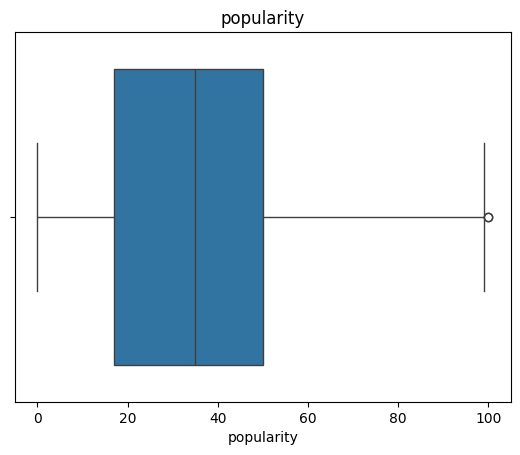

In [14]:
sns.boxplot(
    x=df['popularity']
)

plt.title("popularity")

plt.show()


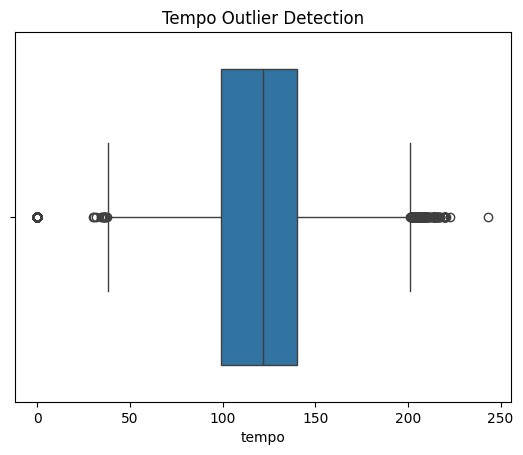

In [15]:
sns.boxplot(
    x=df['tempo']
)

plt.title("Tempo Outlier Detection")

plt.show()


### INSIGHTS:
### WHY TEMPO ONLY ?
* I checked outliers in the tempo column because extreme tempo values can affect model accuracy.
* Removing them helps improve model stability and prediction performance.



## 8.2 Remove Outliers Using IQR Method

In [16]:
# OUTLIER HANDLING USING IQR

Q1 = df['tempo'].quantile(0.25)

Q3 = df['tempo'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

df = df[
    (df['tempo'] >= lower) &
    (df['tempo'] <= upper)
]

## 8.3 Visualization of Outliers after IQR

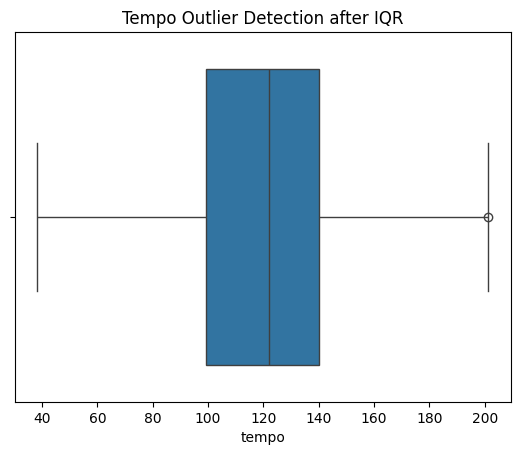

In [17]:
sns.boxplot(
    x=df['tempo']
)

plt.title("Tempo Outlier Detection after IQR")

plt.show()



## **9. Exploratory Data Analysis (EDA)**


## 9.1 Univarient Analysis

### Question 1 : What is the distribution of hit songs and non-hit songs in the Spotify dataset?

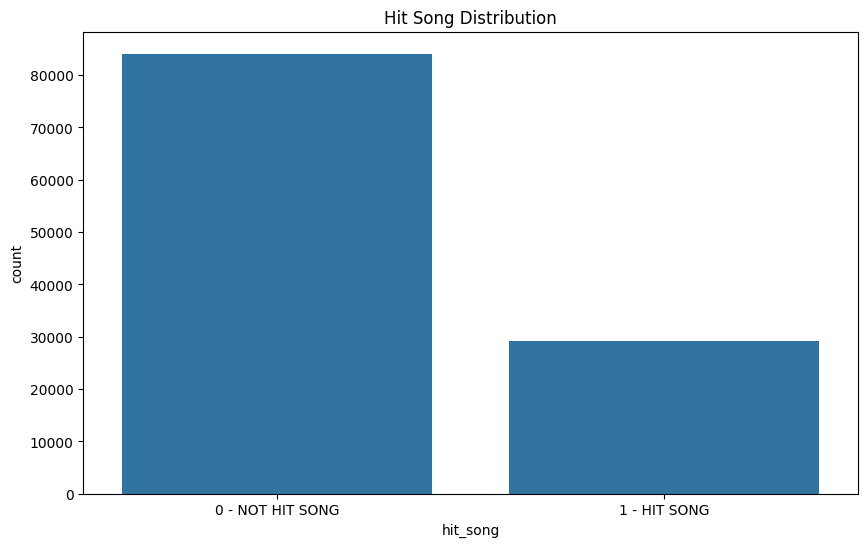

In [18]:
plt.figure(figsize=(10,6))

sns.countplot(x='hit_song', data=df)

plt.xticks(
    ticks=[0,1],
    labels=['0 - NOT HIT SONG', '1 - HIT SONG']
)

plt.title('Hit Song Distribution')

plt.show()

### Insight:
#### The graph shows that non-hit songs are more common than hit songs in the dataset. This indicates that achieving hit-song status is relatively difficult, and only a smaller portion of songs become highly popular.


### Question 2 : “How are the numerical features distributed in the Spotify dataset?”

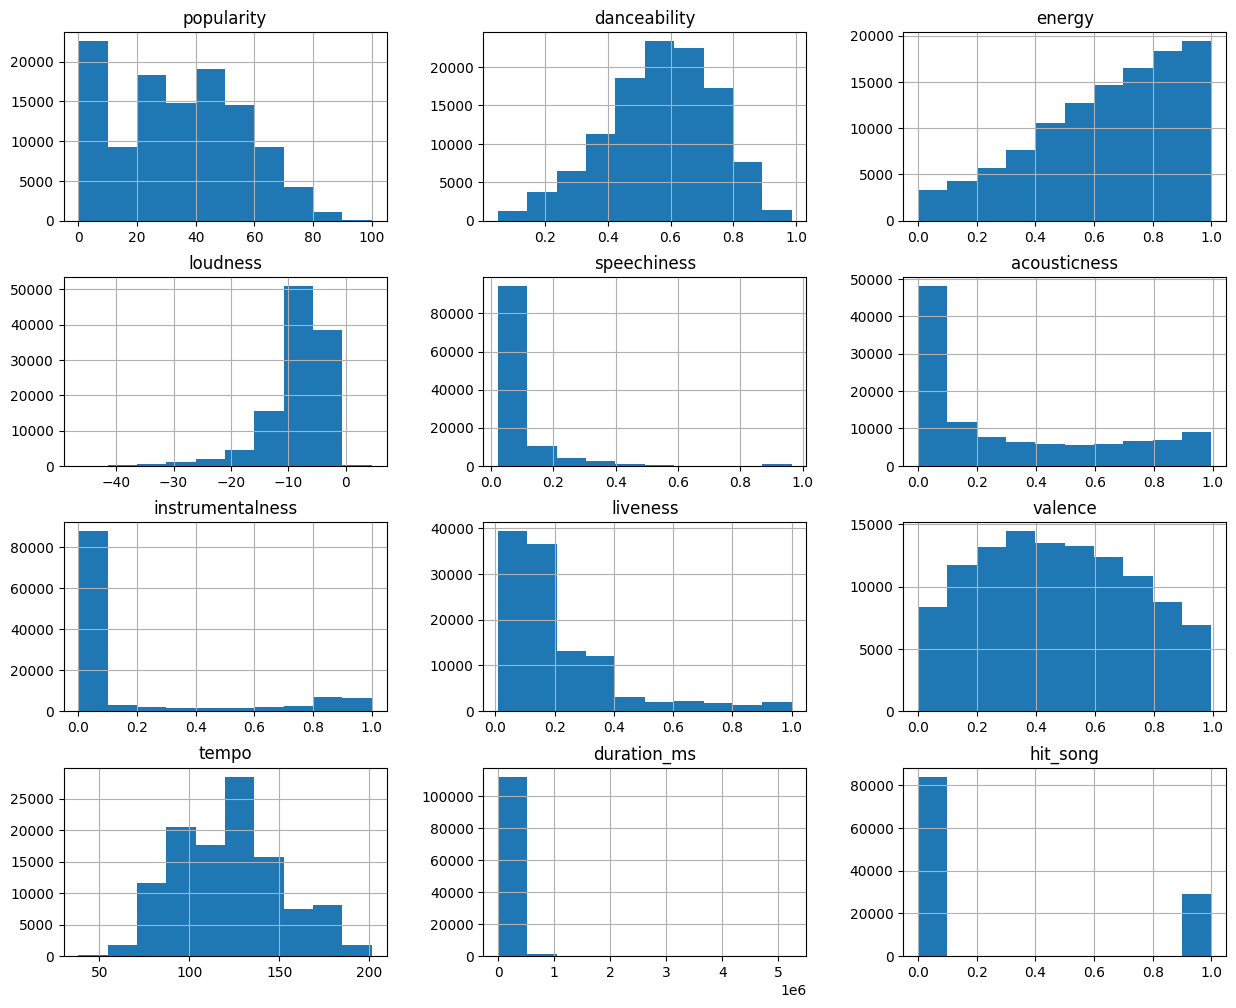

In [19]:
df.hist(figsize=(15,12))
plt.show()

### Insight:
#### The histograms show how the values of each feature are distributed across the dataset, making it easier to understand overall song patterns and trends.


## 9.2 BIVARIATE ANALYSIS

### Question 1 : “Does higher energy in songs increase popularity?”

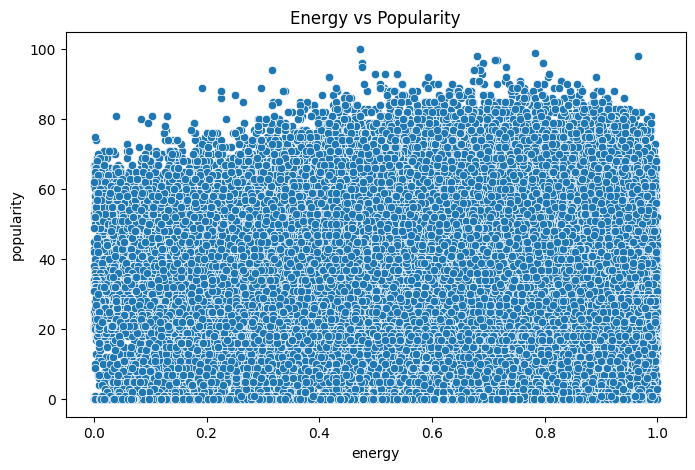

In [20]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='energy',
    y='popularity',
    data=df
)

plt.title("Energy vs Popularity")

plt.show()

### Insight:
* Songs with high energy levels tend to achieve better popularity scores, although the relationship is not perfectly linear.
* Energetic songs generally attract more listeners.

### Question 2 : “What relationship exists between acousticness and energy?”

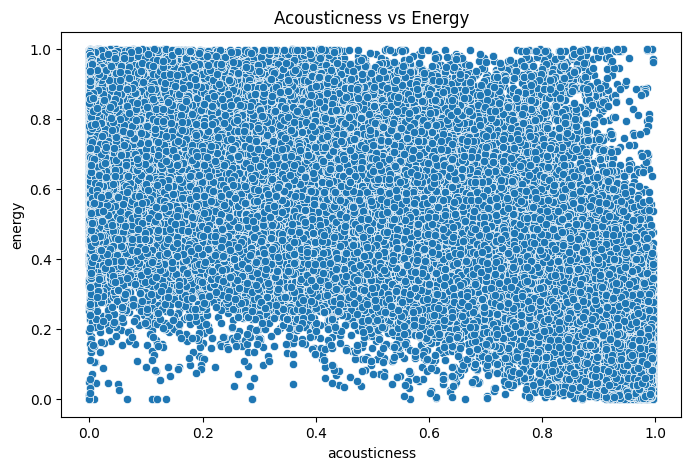

In [21]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='acousticness',
    y='energy',
    data=df
)

plt.title("Acousticness vs Energy")

plt.show()

### Insight
* Songs with high acousticness usually have lower energy levels.
* This indicates that acoustic songs are generally softer and less intense.

## 9.3 Multivarient Analysis

### Question 1 : “How do multiple audio features interact with hit-song classification?”

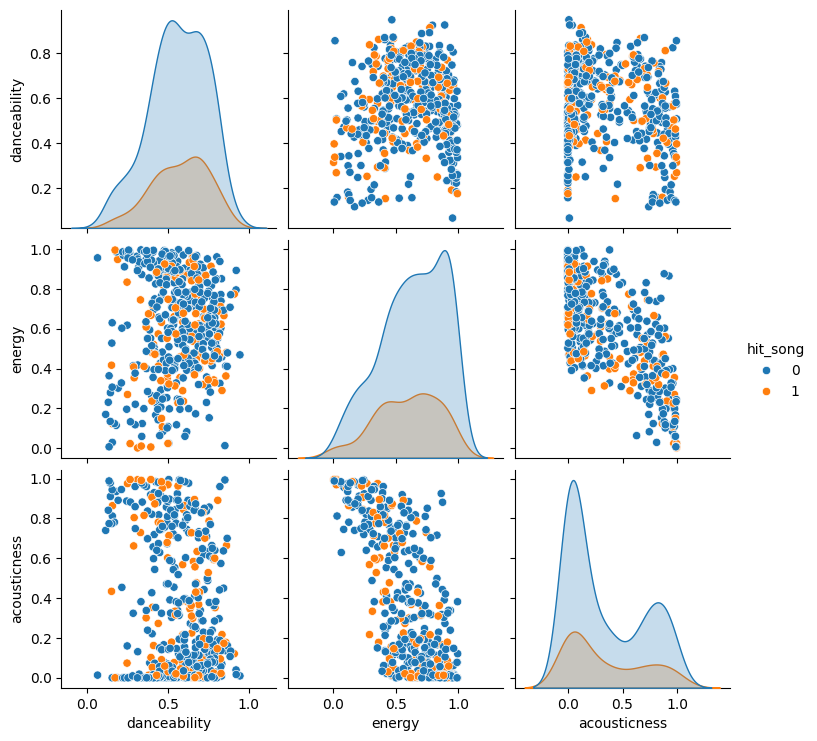

In [22]:
features = [
    'danceability',
    'energy',
    'acousticness',
    'hit_song'
]

sample_df = df.sample(500)

sns.pairplot(
    sample_df[features],
    hue='hit_song'
)

plt.show()

### Insight
* Hit songs tend to cluster around higher danceability and energy values.
* The graph also helps visualize how different features combine to influence song success.

### Question 2 : “Which Spotify audio features are positively or negatively correlated with each other?”

### Correlation Heatmap

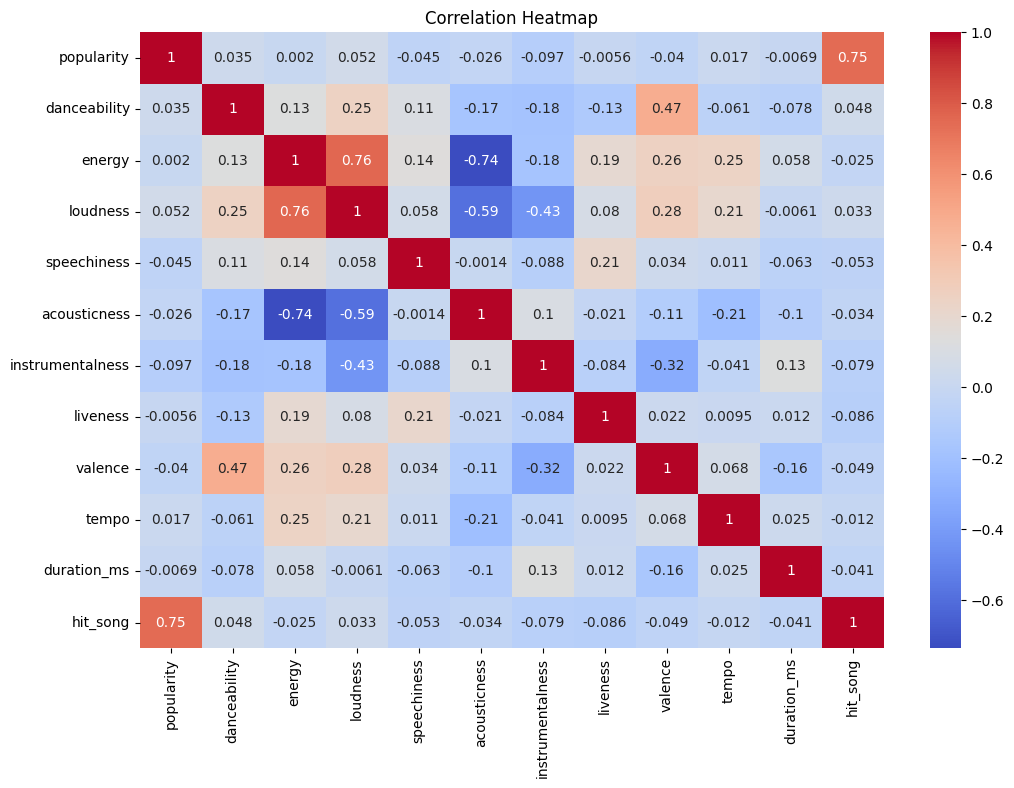

In [23]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm',
    annot=True
)

plt.title('Correlation Heatmap')

plt.show()

### Insight:
####  The heatmap shows relationships between audio features. Energy and loudness are positively correlated, while acousticness is negatively related to energy.



## **10. Encoding Categorical Variables**


In [24]:

le = LabelEncoder()

df['track_genre'] = le.fit_transform(df['track_genre'])

df.head()


,popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,track_genre,hit_song
0,73,0.676,0.4610,-6.746,0.1430,0.0322,0.000001,0.3580,0.715,87.917,230666,0,1
1,55,0.420,0.1660,-17.235,0.0763,0.9240,0.000006,0.1010,0.267,77.489,149610,0,1
2,57,0.438,0.3590,-9.734,0.0557,0.2100,0.000000,0.1170,0.120,76.332,210826,0,1
3,71,0.266,0.0596,-18.515,0.0363,0.9050,0.000071,0.1320,0.143,181.740,201933,0,1
4,82,0.618,0.4430,-9.681,0.0526,0.4690,0.000000,0.0829,0.167,119.949,198853,0,1


In [25]:
for i, genre in enumerate(le.classes_):
    print(i, "=", genre)

0 = acoustic
1 = afrobeat
2 = alt-rock
3 = alternative
4 = ambient
5 = anime
6 = black-metal
7 = bluegrass
8 = blues
9 = brazil
10 = breakbeat
11 = british
12 = cantopop
13 = chicago-house
14 = children
15 = chill
16 = classical
17 = club
18 = comedy
19 = country
20 = dance
21 = dancehall
22 = death-metal
23 = deep-house
24 = detroit-techno
25 = disco
26 = disney
27 = drum-and-bass
28 = dub
29 = dubstep
30 = edm
31 = electro
32 = electronic
33 = emo
34 = folk
35 = forro
36 = french
37 = funk
38 = garage
39 = german
40 = gospel
41 = goth
42 = grindcore
43 = groove
44 = grunge
45 = guitar
46 = happy
47 = hard-rock
48 = hardcore
49 = hardstyle
50 = heavy-metal
51 = hip-hop
52 = honky-tonk
53 = house
54 = idm
55 = indian
56 = indie
57 = indie-pop
58 = industrial
59 = iranian
60 = j-dance
61 = j-idol
62 = j-pop
63 = j-rock
64 = jazz
65 = k-pop
66 = kids
67 = latin
68 = latino
69 = malay
70 = mandopop
71 = metal
72 = metalcore
73 = minimal-techno
74 = mpb
75 = new-age
76 = opera
77 = pagode


### Insight:
#### Music genres were converted into numerical values so the Machine Learning model could understand and process them properly.


## **11. Define Features, Target and Train-Test Split**

In [26]:
X = df.drop(['hit_song','popularity'], axis=1)
y = df['hit_song']

### Reason:
* popularity created hit_song
* keeping it causes data leakage

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,   
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(90706, 11)
(22677, 11)


### Insight:
* Initially the model showed 100% accuracy due to data leakage because popularity was used to create the target variable.
*  After removing the leakage column, the model achieved realistic performance and genuine prediction capability.

## **12. Feature Scaling**

In [28]:

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


### Insight:
#### Feature scaling was applied to bring all values to a similar range, helping the Machine Learning models perform more accurately and efficiently.



## **13.Supervised Machine Learning Algorithms**


## 13.1 Logistic Regression

In [29]:
lr = LogisticRegression(class_weight='balanced')

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

## 13.2 KNN

In [30]:
knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

pred_knn = knn.predict(X_test)

## 13.3 Decision Tree

In [31]:
dt = DecisionTreeClassifier(random_state=42, class_weight='balanced')

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

## 13.4 Random Forest

In [32]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [33]:

print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

           0       0.84      0.97      0.90     16853
           1       0.83      0.46      0.59      5824

    accuracy                           0.84     22677
   macro avg       0.83      0.71      0.74     22677
weighted avg       0.84      0.84      0.82     22677



In [34]:
df['hit_song'].value_counts()

hit_song
0    84131
1    29252
Name: count, dtype: int64

## 13.5 AdaBoost

In [35]:
ab = AdaBoostClassifier()

ab.fit(X_train, y_train)

pred_ab = ab.predict(X_test)

## 13.6 Gradient Boosting

In [36]:

gb = GradientBoostingClassifier(random_state = 42)

gb.fit(X_train, y_train)

pred_gb = gb.predict(X_test)


## 13.7 SVM

In [37]:
svm = SVC(class_weight= 'balanced')

svm.fit(X_train, y_train)

pred_svm = svm.predict(X_test)


## 13.8 NAIVE BAYES

In [38]:
nb = GaussianNB()

nb.fit(X_train, y_train)

pred_nb = nb.predict(X_test)

## **14. Models Evaluation and Accuracy Comparison**

In [57]:
models = {
    "Logistic Regression": pred_lr,
    "Decision Tree": pred_dt,
    "Random Forest": pred_rf,
    "Gradient Boosting": pred_gb,
    "ADA Boost": pred_ab,
    "SVM": pred_svm,
    "KNN": pred_knn,
    "Naive Bayes": pred_nb
}

for name, pred in models.items():

    acc = accuracy_score(y_test, pred)

    print(f"{name}  : {acc*100:.2f}%")

Logistic Regression  : 55.91%
Decision Tree  : 77.27%
Random Forest  : 83.64%
Gradient Boosting  : 76.27%
ADA Boost  : 74.32%
SVM  : 59.01%
KNN  : 74.56%
Naive Bayes  : 60.45%


### Insight:
#### Different Machine Learning algorithms were compared to identify which model gives the most accurate prediction for hit songs.


## **15. BEST MODEL**

In [40]:
best_model = ""
best_accuracy = 0

for name, pred in models.items():

    acc = accuracy_score(y_test, pred)

    if acc > best_accuracy:
        best_accuracy = acc
        best_model = name
print()
print("Best Model:", best_model)
print(f"Best Accuracy: {best_accuracy*100:.2f}%")
print()


Best Model: Random Forest
Best Accuracy: 83.64%



In [41]:
final_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')


final_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### Insight:
#### The models were sorted based on accuracy to easily identify the best-performing algorithm for hit song prediction.


## **16. Confusion Matrix**

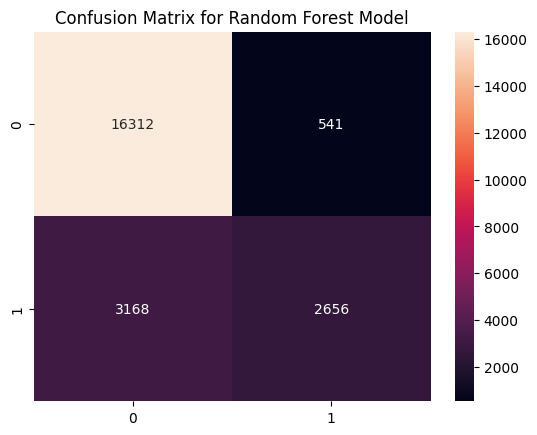

In [42]:
cm = confusion_matrix(y_test, pred_rf)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix for Random Forest Model")

plt.show()

### Insight : The confusion matrix shows that the model correctly predicted most songs with very few errors.
#### To minimize these errors and predicting more accurately, we will be using SMOTE function in final model to improve model efficiency. 



## **17. Recommendation Style Analysis**

In [43]:

top_songs = df.sort_values(by='popularity', ascending=False)

top_songs.head(10)


,popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,track_genre,hit_song
20001,100,0.714,0.472,-7.375,0.0864,0.01300,0.000005,0.266,0.238,131.121,156943,20,1
81051,100,0.714,0.472,-7.375,0.0864,0.01300,0.000005,0.266,0.238,131.121,156943,80,1
51664,99,0.621,0.782,-5.548,0.0440,0.01250,0.033000,0.230,0.550,128.033,198937,51,1
89411,98,0.835,0.679,-5.329,0.0364,0.58300,0.000002,0.218,0.850,124.980,162637,89,1
67356,98,0.835,0.679,-5.329,0.0364,0.58300,0.000002,0.218,0.850,124.980,162637,67,1
88410,98,0.835,0.679,-5.329,0.0364,0.58300,0.000002,0.218,0.850,124.980,162637,88,1
81210,98,0.561,0.965,-3.673,0.0343,0.00383,0.000007,0.371,0.304,128.040,175238,80,1
68303,98,0.835,0.679,-5.329,0.0364,0.58300,0.000002,0.218,0.850,124.980,162637,68,1
30003,98,0.561,0.965,-3.673,0.0343,0.00383,0.000007,0.371,0.304,128.040,175238,30,1
20008,98,0.561,0.965,-3.673,0.0343,0.00383,0.000007,0.371,0.304,128.040,175238,20,1


### Insight: 
#### The songs were sorted by popularity to identify the top-performing tracks with the highest listener engagement.


## **18. Final Model**

### Smote

In [44]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

# SMOTE
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

# Train model
rf_smote = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_smote.fit(X_train_smote, y_train_smote)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [45]:
probs = rf_smote.predict_proba(X_test)[:,1]

pred_30 = (probs >= 0.30).astype(int)

In [46]:
print(hasattr(rf_smote, "estimators_"))

True


In [47]:
from sklearn.metrics import classification_report

probs = rf_smote.predict_proba(X_test)[:,1]

for t in [0.5,0.4,0.3,0.25,0.2]:
    pred = (probs >= t).astype(int)

    print(f"\nThreshold={t}")
    print(classification_report(y_test,pred))


Threshold=0.5
              precision    recall  f1-score   support

           0       0.89      0.88      0.88     16853
           1       0.65      0.68      0.67      5824

    accuracy                           0.83     22677
   macro avg       0.77      0.78      0.77     22677
weighted avg       0.83      0.83      0.83     22677


Threshold=0.4
              precision    recall  f1-score   support

           0       0.92      0.76      0.83     16853
           1       0.54      0.81      0.65      5824

    accuracy                           0.78     22677
   macro avg       0.73      0.79      0.74     22677
weighted avg       0.82      0.78      0.79     22677


Threshold=0.3
              precision    recall  f1-score   support

           0       0.95      0.61      0.74     16853
           1       0.45      0.90      0.60      5824

    accuracy                           0.69     22677
   macro avg       0.70      0.76      0.67     22677
weighted avg       0.82      

In [48]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Predictions
y_pred_smote = rf_smote.predict(X_test)

# Probabilities for ROC-AUC
y_prob_smote = rf_smote.predict_proba(X_test)[:,1]

# Metrics
accuracy = accuracy_score(y_test, y_pred_smote)
precision = precision_score(y_test, y_pred_smote)
recall = recall_score(y_test, y_pred_smote)
f1 = f1_score(y_test, y_pred_smote)
auc = roc_auc_score(y_test, y_prob_smote)

print("Accuracy :", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))
print("F1 Score :", round(f1,4))
print("ROC-AUC  :", round(auc,4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_smote))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_smote))

Accuracy : 0.8278
Precision: 0.6624
Recall   : 0.6722
F1 Score : 0.6673
ROC-AUC  : 0.8705

Confusion Matrix:
[[14858  1995]
 [ 1909  3915]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.88      0.88     16853
           1       0.66      0.67      0.67      5824

    accuracy                           0.83     22677
   macro avg       0.77      0.78      0.78     22677
weighted avg       0.83      0.83      0.83     22677



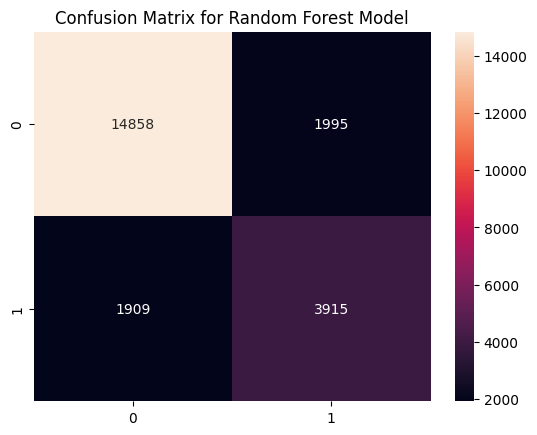

In [49]:
cm = confusion_matrix(y_test, y_pred_smote)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix for Random Forest Model")

plt.show()

## Overall Result
* The project was successful in building an accurate and reliable Spotify hit song prediction system with 82.78% accuracy
* The Random Forest model proved to be highly effective for predicting whether a song is likely to become a hit based on its audio features.

## **19. Save and Load the model**

### SAVE MODEL

joblib.dump(
    rf_smote,
    'spotify_ml_final_model.pkl'
)
print("Model Saved Successfully!!")

### SAVE SCALER

joblib.dump(
    scaler,
    'spotify_ml_scaler_final.pkl'
)
print("Scaler Saved Successfully!!")

### LOAD MODEL

loaded_model = joblib.load(
    'spotify_ml_final_model.pkl'
)
print("Model Loded Successfully!!")

##### The trained Random Forest model was loaded successfully, allowing predictions to be made without training the model again.


## **20. Prediction on Sample data**

In [58]:
# 1. Create selected columns list *without* the target variable and popularity
# As popularity >70 = hit song, So the target is directly dependent on popularity.

prediction_columns = [col for col in selected_columns 
                      if col not in ['hit_song', 'popularity']]

# 2. Create the sample data with exactly 12 values (removed the 0 at the end)
sample_data = pd.DataFrame([[
    0.82,         # danceability
    0.91,         # energy
    -5.4,         # loudness
    0.12,         # speechiness
    0.05,         # acousticness
    0.0,          # instrumentalness
    0.15,         # liveness
    0.86,         # valence
    125.0,        # tempo
    210000,       # duration_ms
    1             # track_genre (encoded numeric value)
]], columns=prediction_columns)

# 3. Predict using best model
sample_data_scaled = scaler.transform(sample_data)

prediction = rf_smote.predict(sample_data_scaled)
# 4. DISPLAY PREDICTION

print("\nSAMPLE PREDICTION\n")
print(prediction)

if prediction[0] == 1:

    print("Hit Song")

else:

    print("Not Hit Song")


SAMPLE PREDICTION

[0]
Not Hit Song


## **21. Actual vs predicted on random dataset records**

#### Example :

In [60]:
# Pick any song from dataset
song = df.sample(1)

actual = song['hit_song'].values[0]

sample_data = song[prediction_columns]

prediction = rf_smote.predict(sample_data)[0]

print("Actual:", actual)
print("Predicted:", prediction)

Actual: 0
Predicted: 0


In [55]:
display(song)

,popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,track_genre,hit_song
35972,36,0.833,0.916,-2.763,0.0436,0.159,0.0,0.244,0.963,96.013,203102,35,0


## **22. Predictions on user input**

In [56]:
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

# =========================================================
# INPUT VALIDATION FUNCTION
# =========================================================

def get_valid_input(message, min_val, max_val):

    while True:

        value = float(input(message))

        if min_val <= value <= max_val:
            return value

        print(f"Invalid! Enter value between {min_val} and {max_val}")

# =========================================================
# GENRE LIST
# =========================================================

genres = [
    "acoustic","afrobeat","alt-rock","alternative","ambient",
    "anime","black-metal","bluegrass","blues","brazil",
    "breakbeat","british","cantopop","chicago-house","children",
    "chill","classical","club","comedy","country",
    "dance","dancehall","death-metal","deep-house","detroit-techno",
    "disco","disney","drum-and-bass","dub","dubstep",
    "edm","electro","electronic","emo","folk",
    "forro","french","funk","garage","german",
    "gospel","goth","grindcore","groove","grunge",
    "guitar","happy","hard-rock","hardcore","hardstyle",
    "heavy-metal","hip-hop","honky-tonk","house","idm",
    "indian","indie","indie-pop","industrial","iranian",
    "j-dance","j-idol","j-pop","j-rock","jazz",
    "k-pop","kids","latin","latino","malay",
    "mandopop","metal","metalcore","minimal-techno","mpb",
    "new-age","opera","pagode","party","piano",
    "pop","pop-film","power-pop","progressive-house","psych-rock",
    "punk","punk-rock","r-n-b","reggae","reggaeton",
    "rock","rock-n-roll","rockabilly","romance","sad",
    "salsa","samba","sertanejo","show-tunes","singer-songwriter",
    "ska","sleep","songwriter","soul","spanish",
    "study","swedish","synth-pop","tango","techno",
    "trance","trip-hop","turkish","world-music"
]

# =========================================================
# DROPDOWN
# =========================================================

genre_dropdown = widgets.Dropdown(
    options=genres,
    description='Genre:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)

display(genre_dropdown)

# =========================================================
# USER INPUTS WITH VALIDATION
# =========================================================

danceability = get_valid_input(
    "Danceability [0-1]: ",
    0,
    1
)

energy = get_valid_input(
    "Energy [0-1]: ",
    0,
    1
)

loudness = get_valid_input(
    "Loudness [-60 to 0]: ",
    -60,
    0
)

speechiness = get_valid_input(
    "Speechiness [0-1]: ",
    0,
    1
)

acousticness = get_valid_input(
    "Acousticness [0-1]: ",
    0,
    1
)

instrumentalness = get_valid_input(
    "Instrumentalness [0-1]: ",
    0,
    1
)

liveness = get_valid_input(
    "Liveness [0-1]: ",
    0,
    1
)

valence = get_valid_input(
    "Valence [0-1]: ",
    0,
    1
)

tempo = get_valid_input(
    "Tempo BPM [40-250]: ",
    40,
    250
)

duration_ms = get_valid_input(
    "Duration in ms [30000-600000]: ",
    30000,
    600000
)

# =========================================================
# GET SELECTED GENRE
# =========================================================

selected_genre = genre_dropdown.value

track_genre = genres.index(selected_genre)

print("\nSelected Genre :", selected_genre)
print("Genre Code     :", track_genre)

# =========================================================
# CREATE DATAFRAME
# =========================================================

sample_data = pd.DataFrame([[
    danceability,
    energy,
    loudness,
    speechiness,
    acousticness,
    instrumentalness,
    liveness,
    valence,
    tempo,
    duration_ms,
    track_genre
]], columns=[
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo',
    'duration_ms',
    'track_genre'
])

# =========================================================
# PREDICTION
# =========================================================

probability = rf_smote.predict_proba(sample_data)[0][1]

prediction = 1 if probability >= 0.30 else 0

# =========================================================
# OUTPUT
# =========================================================

print("\n==============================")

if prediction == 1:
    print("Prediction : HIT SONG")
else:
    print("Prediction : NOT HIT SONG")

print(f"Genre           : {selected_genre}")
print(f"Hit Probability : {probability*100:.2f}%")

# =========================================================
# CONFIDENCE
# =========================================================

if probability >= 0.70:
    print("Confidence      : HIGH")

elif probability >= 0.40:
    print("Confidence      : MEDIUM")

else:
    print("Confidence      : LOW")

print("==============================")

Dropdown(description='Genre:', layout=Layout(width='400px'), options=('acoustic', 'afrobeat', 'alt-rock', 'alt…

Danceability [0-1]:  9


Invalid! Enter value between 0 and 1


Danceability [0-1]:  0.43
Energy [0-1]:  0.95
Loudness [-60 to 0]:  -7
Speechiness [0-1]:  0.98
Acousticness [0-1]:  0.44
Instrumentalness [0-1]:  0.32
Liveness [0-1]:  0.89
Valence [0-1]:  0.65
Tempo BPM [40-250]:  248
Duration in ms [30000-600000]:  250000



Selected Genre : pop
Genre Code     : 80

Prediction : NOT HIT SONG
Genre           : pop
Hit Probability : 17.00%
Confidence      : LOW


# Final Conclusion

* The Spotify Hit Song Prediction model was successfully developed using Machine Learning.

* Multiple algorithms were tested, and Random Forest gave the best performance.

* The final model achieved **82.78% accuracy**, showing strong prediction capability for identifying hit songs.

* Features like danceability, energy, loudness, tempo, and valence had a major impact on song popularity.

* Random Forest performed well because it handled complex patterns and reduced overfitting effectively.

# Key Insights

* Hit songs generally had higher energy and danceability.

* Balanced musical features increased the chances of a song becoming popular.

* Audio characteristics can be used to predict song success with good accuracy.

* The project shows how Machine Learning can help understand audience music preferences.
